# Coffee Cart Sales Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/coffee_sales.csv")
df.head()

,date,product,quantity,unit_price
0,2026-01-05,Drip Coffee,6,2.75
1,2026-01-05,Latte,20,4.50
2,2026-01-05,Espresso,18,3.00
3,2026-01-06,Drip Coffee,13,2.75
4,2026-01-06,Latte,13,4.50


In [3]:
df["revenue"] = df["quantity"] * df["unit_price"]
df.head()

,date,product,quantity,unit_price,revenue
0,2026-01-05,Drip Coffee,6,2.75,16.50
1,2026-01-05,Latte,20,4.50,90.00
2,2026-01-05,Espresso,18,3.00,54.00
3,2026-01-06,Drip Coffee,13,2.75,35.75
4,2026-01-06,Latte,13,4.50,58.50


### Daily revenue

In [4]:
daily = df.groupby("date")["revenue"].sum()
avg_daily = daily.mean()
daily

date
2026-01-05    160.50
2026-01-06    160.25
2026-01-07    124.50
2026-01-08    156.00
2026-01-09    199.25
2026-01-10    143.50
2026-01-11    165.75
2026-01-12    138.00
2026-01-13    170.50
2026-01-14    164.25
Name: revenue, dtype: float64

### Average Daily Revenue

In [5]:
print(f"Average daily revenue: ${avg_daily:.2f}")

Average daily revenue: $158.25


### Compare revenue: random 50/50 split of the days

In [6]:
shuffled = df.sample(frac=1, random_state=50)
half = len(shuffled) // 2
group_a = shuffled.iloc[:half]
group_b = shuffled.iloc[half:]
print(f"Group A mean revenue: {group_a['revenue'].mean():.2f}")
print(f"Group B mean revenue: {group_b['revenue'].mean():.2f}")

Group A mean revenue: 47.77
Group B mean revenue: 57.73


### Revenue by product

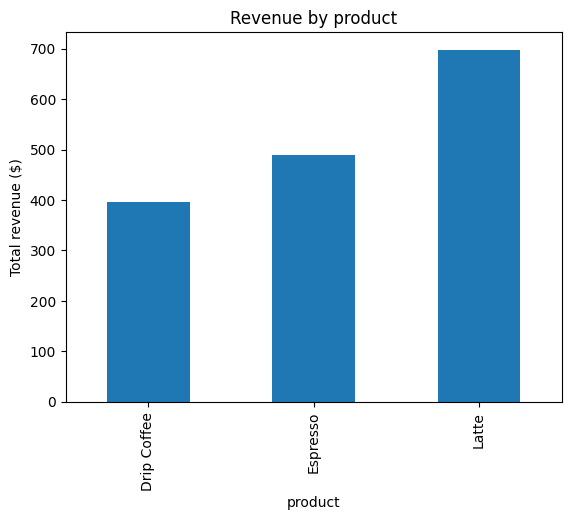

In [7]:
by_product = df.groupby("product")["revenue"].sum()
by_product.plot(kind="bar")
plt.ylabel("Total revenue ($)")
plt.title("Revenue by product")
plt.savefig("../output/revenue_by_product.png")
plt.show()

### Takeaway
Latte brings in the most total revenue this month.